In [1]:
!pip -q install -U transformers datasets accelerate evaluate jiwer librosa soundfile torchaudio peft matplotlib

In [2]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive/carecaller/LoRA-ft-emergency')
MANIFEST = BASE_DIR / 'emergency_manifest.csv'
OUTPUT_DIR = BASE_DIR / 'whisper_tiny_emergency'
SAMPLE_RATE = 16000
MODEL_ID = 'openai/whisper-tiny'
LANGUAGE = 'english'
TASK = 'transcribe'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('manifest:', MANIFEST)
print('output:', OUTPUT_DIR)
if not MANIFEST.exists():
    raise FileNotFoundError(f'Manifest not found: {MANIFEST}')


manifest: /content/drive/MyDrive/carecaller/LoRA-ft-emergency/emergency_manifest.csv
output: /content/drive/MyDrive/carecaller/LoRA-ft-emergency/whisper_tiny_emergency


In [4]:
import os
from datasets import Audio, DatasetDict, load_dataset

BASE_DIR = '/content/drive/MyDrive/carecaller/LoRA-ft-emergency'

# load manifest
data = load_dataset("csv", data_files={"train": str(MANIFEST)})["train"]

# drop unnecessary columns
data = data.select_columns(['audio_path', 'text'])

# fix path column
def fix_directory_path(example):
    corrected_relative_path = example['audio_path'].replace('audio/', 'emergency_clips/')
    example['audio_path'] = os.path.join(BASE_DIR, corrected_relative_path)
    return example

data = data.map(fix_directory_path)

# validate fix
def file_exists(example):
    return os.path.exists(example['audio_path'])

initial_count = len(data)
data = data.filter(file_exists)
print(f"Dropped {initial_count - len(data)} missing files. Valid rows remaining: {len(data)}")

# dynamic split
split_1 = data.train_test_split(train_size=250, seed=42)
train_ds = split_1['train']
temp_ds = split_1['test']

split_2 = temp_ds.train_test_split(test_size=0.5, seed=42)
val_ds = split_2['train']
test_ds = split_2['test']

# add split column back
train_ds = train_ds.add_column('split', ['train'] * len(train_ds))
val_ds = val_ds.add_column('split', ['val'] * len(val_ds))
test_ds = test_ds.add_column('split', ['test'] * len(test_ds))

# build final dataset
ds = DatasetDict({
    'train': train_ds,
    'validation': val_ds,
    'test': test_ds
})

ds = ds.cast_column('audio_path', Audio(sampling_rate=16000))
ds

Dropped 0 missing files. Valid rows remaining: 350


DatasetDict({
    train: Dataset({
        features: ['audio_path', 'text', 'split'],
        num_rows: 250
    })
    validation: Dataset({
        features: ['audio_path', 'text', 'split'],
        num_rows: 50
    })
    test: Dataset({
        features: ['audio_path', 'text', 'split'],
        num_rows: 50
    })
})

In [5]:
# upgrade torchao package due to error
!pip install -U torchao

In [11]:
import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from peft import LoraConfig, get_peft_model

# load the base processor and model
processor = WhisperProcessor.from_pretrained(MODEL_ID, language=LANGUAGE, task=TASK)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID)

model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language=LANGUAGE, task=TASK)
model.config.suppress_tokens = []
model.config.use_cache = False

# LoRA wrapper
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.125,
    bias="none"
)
model = get_peft_model(model, lora_config)

# check for amt of paramaters trained
model.print_trainable_parameters()

# ensure we're using gpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

trainable params: 589,824 || all params: 38,350,464 || trainable%: 1.5380
device: cuda


In [7]:
# preps wav files for training - creates a Log-Mel Spectogram
def prepare_batch(batch):
    audio = batch['audio_path']
    batch['input_features'] = processor.feature_extractor(
        audio['array'],
        sampling_rate=audio['sampling_rate'],
    ).input_features[0]

    # tokenizer creates numerical labels for loss calculation
    batch['labels'] = processor.tokenizer(batch['text']).input_ids
    batch['input_length'] = len(audio['array']) / audio['sampling_rate']
    return batch

ds = ds.map(
    prepare_batch,
    remove_columns=ds['train'].column_names,
    num_proc=1,
)

MAX_AUDIO_SECONDS = 30.0
ds['train'] = ds['train'].filter(lambda x: x['input_length'] < MAX_AUDIO_SECONDS)
ds['validation'] = ds['validation'].filter(lambda x: x['input_length'] < MAX_AUDIO_SECONDS)
ds['test'] = ds['test'].filter(lambda x: x['input_length'] < MAX_AUDIO_SECONDS)

ds


DatasetDict({
    train: Dataset({
        features: ['input_features', 'labels', 'input_length'],
        num_rows: 250
    })
    validation: Dataset({
        features: ['input_features', 'labels', 'input_length'],
        num_rows: 50
    })
    test: Dataset({
        features: ['input_features', 'labels', 'input_length'],
        num_rows: 50
    })
})

In [8]:
# padding - ensures shorter samples are filled with special tokens

from dataclasses import dataclass
from typing import Any, Dict, List, Union

import torch

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:

        # pads audio tensors
        input_features = [{'input_features': feature['input_features']} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors='pt')

        # pads text tensors
        label_features = [{'input_ids': feature['labels']} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors='pt')


        # loss masking - only calculates loss for words, hides padding
        labels = labels_batch['input_ids'].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # slices BOS token
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch['labels'] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)


In [9]:
import evaluate

wer_metric = evaluate.load('wer')
cer_metric = evaluate.load('cer')

# computes metrics - converts to percentages
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * wer_metric.compute(predictions=pred_str, references=label_str)
    cer = 100 * cer_metric.compute(predictions=pred_str, references=label_str)
    return {'wer': wer, 'cer': cer}


In [12]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    # LoRA settings (differs from fully fine-tuned)
    learning_rate=2e-4, # more stable
    num_train_epochs=8,
    weight_decay=0.01,
    warmup_steps=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',

    gradient_checkpointing=True,
    fp16=torch.cuda.is_available(),
    logging_steps=25,
    predict_with_generate=True,
    generation_max_length=225,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='wer',
    greater_is_better=False,
    report_to='none',
)

In [13]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=ds['train'],
    eval_dataset=ds['validation'],
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Wer,Cer
1,No log,1.901242,54.438738,32.601399
2,3.885905,1.297043,37.931034,29.566434
3,3.885905,1.186405,38.958180,26.979021
4,1.957103,1.119354,20.029347,18.405594
5,1.506185,1.076326,19.809244,18.307692
6,1.506185,1.045514,19.442406,12.853147
7,1.298934,1.028365,19.369039,12.699301
8,1.161488,1.019696,19.955979,13.608392


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.log

TrainOutput(global_step=128, training_loss=1.948130663484335, metrics={'train_runtime': 417.773, 'train_samples_per_second': 4.787, 'train_steps_per_second': 0.306, 'total_flos': 5.093646336e+16, 'train_loss': 1.948130663484335, 'epoch': 8.0})

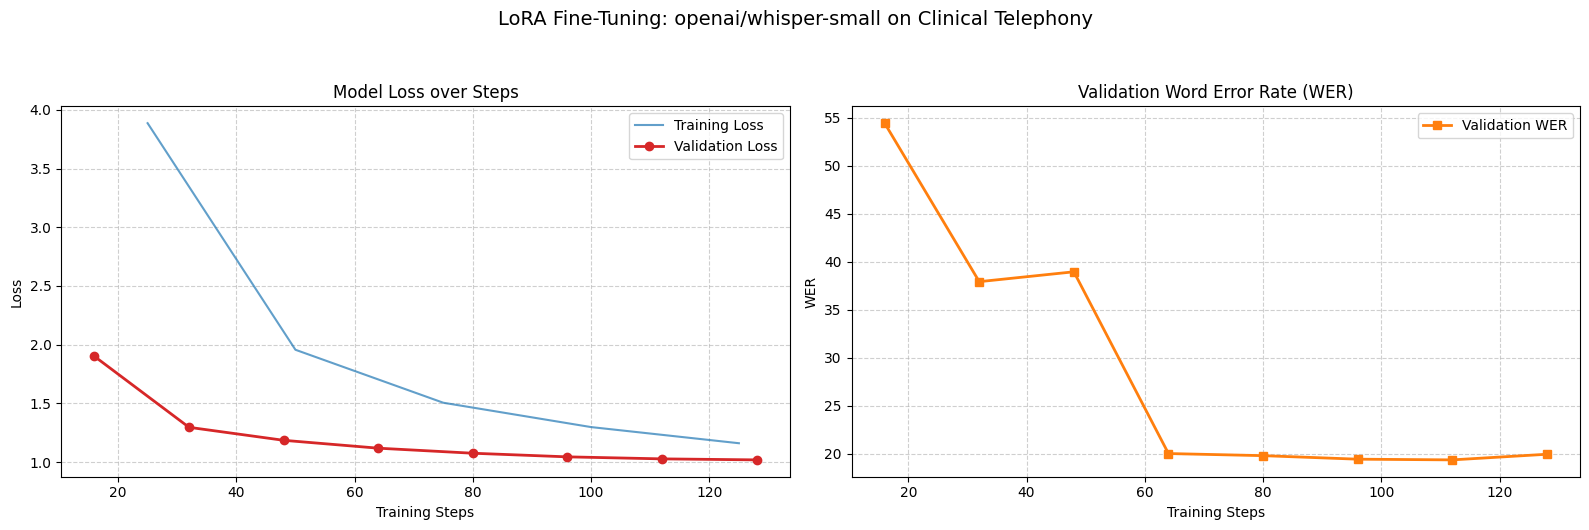

In [14]:
# Training history visualization

import matplotlib.pyplot as plt

# Pull the log history directly from the trainer memory
log_history = trainer.state.log_history

train_steps = []
train_loss = []
eval_steps = []
eval_loss = []
eval_wer = []

# Parse the Hugging Face log dictionaries
for entry in log_history:
    # Training logs (happens every `logging_steps`)
    if 'loss' in entry and 'step' in entry:
        train_steps.append(entry['step'])
        train_loss.append(entry['loss'])

    # Evaluation logs (happens at the end of every epoch)
    elif 'eval_loss' in entry and 'step' in entry:
        eval_steps.append(entry['step'])
        eval_loss.append(entry['eval_loss'])
        if 'eval_wer' in entry:
            eval_wer.append(entry['eval_wer'])

# Build the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: Training vs. Validation Loss ---
ax1.plot(train_steps, train_loss, label='Training Loss', color='#1f77b4', alpha=0.7)
ax1.plot(eval_steps, eval_loss, label='Validation Loss', marker='o', color='#d62728', linewidth=2)
ax1.set_title('Model Loss over Steps')
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Word Error Rate (WER) ---
ax2.plot(eval_steps, eval_wer, label='Validation WER', marker='s', color='#ff7f0e', linewidth=2)
ax2.set_title('Validation Word Error Rate (WER)')
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('WER')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('LoRA Fine-Tuning: openai/whisper-small on Clinical Telephony', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [15]:
# After training is done
import json

metrics = trainer.predict(ds['test']).metrics
print(metrics)

final_dir = OUTPUT_DIR / 'final'
trainer.save_model(str(final_dir))
processor.save_pretrained(str(final_dir))

with (final_dir / 'metrics.json').open('w', encoding='utf-8') as handle:
    json.dump(metrics, handle, indent=2)

{'test_loss': 0.7789115309715271, 'test_wer': 20.058997050147493, 'test_cer': 12.547315295107248, 'test_runtime': 10.091, 'test_samples_per_second': 4.955, 'test_steps_per_second': 0.694}


In [18]:
import librosa
import torch
import os
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from pathlib import Path

# Using relative path from root to avoid Hub validation triggers
INFER_DIR = "drive/MyDrive/carecaller/LoRA-ft-emergency/whisper_tiny_emergency/final"
SAMPLE_AUDIO = "/content/drive/MyDrive/carecaller/LoRA-ft-emergency/sample.wav"

print(f"Loading model from local directory: {INFER_DIR}")

if not os.path.isdir(INFER_DIR):
    print(f"Error: Directory not found at {INFER_DIR}")
else:
    # Load processor and model
    processor = WhisperProcessor.from_pretrained(INFER_DIR, local_files_only=True)
    model = WhisperForConditionalGeneration.from_pretrained(INFER_DIR, local_files_only=True).to(device)

    def transcribe_file(path: str) -> str:
        audio, _ = librosa.load(path, sr=16000, mono=True)
        inputs = processor(audio, sampling_rate=16000, return_tensors='pt')
        input_features = inputs.input_features.to(device)

        predicted_ids = model.generate(input_features)
        return processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

    if Path(SAMPLE_AUDIO).exists():
        print("Transcription result:")
        print(transcribe_file(SAMPLE_AUDIO))
    else:
        print(f"File not found: {SAMPLE_AUDIO}")

Loading model from local directory: drive/MyDrive/carecaller/LoRA-ft-emergency/whisper_tiny_emergency/final


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/48 [00:00<?, ?it/s]

Transcription result:
Help my husband just collapsed he clutched his chest he fell he take nitroglytherin I don't know if I should give it to him please hurry up!


In [20]:
import shutil
from google.colab import files
from pathlib import Path

# Define the directory to zip and the output filename
model_path = '/content/drive/MyDrive/carecaller/LoRA-ft-emergency/whisper_tiny_emergency/final'
zip_filename = '/content/whisper_tiny_LoRA_emergency.zip'

if Path(model_path).exists():
    print(f'Zipping model directory: {model_path}')
    shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', model_path)
    print(f'Zip created at: {zip_filename}')

    print('Starting download to your computer...')
    files.download(zip_filename)
else:
    print(f'Error: Model directory not found at {model_path}. Please check if the training and saving cells finished successfully.')

Zipping model directory: /content/drive/MyDrive/carecaller/LoRA-ft-emergency/whisper_tiny_emergency/final
Zip created at: /content/whisper_tiny_LoRA_emergency.zip
Starting download to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>